In [192]:
import copy
import pandas as pd
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from sklearn.metrics import brier_score_loss, classification_report

In [136]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CSV_PATH = "/kaggle/input/datasets/darivi/upside-down-dataset-extra/upside_down_dataset/train.csv"
IMAGE_DIR = "/kaggle/input/datasets/darivi/upside-down-dataset-extra/upside_down_dataset/train"
TEST_DIR = "/kaggle/input/datasets/darivi/upside-down-dataset-extra/upside_down_dataset/test"
OUTPUT_CSV = "submission.csv"
IMG_SIZE = (256, 64)
BATCH_SIZE = 64

print("Device:", DEVICE)

Device: cuda


In [137]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Dataset

In [138]:
df = pd.read_csv(CSV_PATH)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["angle"]
)

In [139]:
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = train_transform

test_transform = val_transform

In [141]:
class TextOrientationDataset(Dataset):

    def __init__(self, df, image_dir, transform=None):
        self.image_dir = Path(IMAGE_DIR)
        self.transform = transform

        self.df = df.reset_index(drop=True)
        # оставляем только те строки, для которых файл реально существует
        mask = self.df.apply(lambda r: (self.image_dir / str(r["angle"]) / r["filename"]).exists(), axis=1)
        self.df = self.df[mask].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self.image_dir / str(row["angle"]) / row["filename"]

        image = Image.open(image_path).convert("RGB")
        label = 0.0 if row["angle"] == 0 else 1.0

        if self.transform:
            image = self.transform(image)

        return image, label

class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = Path(image_dir)
        self.files = sorted([f for f in os.listdir(self.image_dir)])
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = Image.open(self.image_dir / fname).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, fname

In [142]:
train_dataset = TextOrientationDataset(train_df, IMAGE_DIR, train_transform)
val_dataset = TextOrientationDataset(val_df, IMAGE_DIR, val_transform)
test_dataset = TestDataset(TEST_DIR, test_transform)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

loaders = {
    "train": train_loader,
    "valid": val_loader,
    "test": test_loader
}

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 35491
Val: 8873
Test: 20000


# Функции для работы с моделью

In [143]:
def brier_score_fn(y_pred, y_true):
    return brier_score_loss(y_true, y_pred)

In [144]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device).float()
    
        optimizer.zero_grad()
        outp = model(x_batch).view(-1)
        loss = criterion(outp, y_batch)
        loss.backward()
        optimizer.step()
    
        with torch.no_grad():
            total_loss += loss.item() * y_batch.size(0)
            preds = (torch.sigmoid(outp) > 0.5).long()
            correct += (preds == y_batch.long()).sum().item()
            total += y_batch.size(0)

    return total_loss / total, correct / total

In [145]:
def val_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device).float()
    
            outp = model(x_batch).view(-1)
            loss = criterion(outp, y_batch)
            total_loss += loss.item() * y_batch.size(0)
    
            probs = torch.sigmoid(outp)
            preds = (probs > 0.5).long()
            correct += (preds == y_batch.long()).sum().item()
            total += y_batch.size(0)
    
            all_probs.append(probs.cpu())
            all_labels.append(y_batch.cpu())
            all_preds.append(preds.cpu())
    
    if total == 0:
        return 0.0, 0.0, 0.0
    
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()
    
    br_score = brier_score_fn(y_pred=all_probs, y_true=all_labels)
    cm = classification_report(y_true=all_labels, y_pred=all_preds)
    
    return total_loss / total, correct / total, br_score, cm

In [186]:
def all_epoch_cycle(model, loaders, optimizer, criterion, max_epochs, device, scheduler, patience=2, min_delta=1e-4):
    
    model.to(device)

    history = {
        'train_loss': [],
        'train_acc': [],
        'train_br': [],
        'test_loss': [],
        'test_acc': [],
        'test_br': [],
    }

    best_loss = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for epoch in range(max_epochs):
        train_loss, train_acc      = train_one_epoch(model, loaders["train"], optimizer, criterion, device)
        test_loss, test_acc, test_br, cm = val_one_epoch(model, loaders["valid"], criterion, device)

        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['test_br'].append(test_br)

        # Много данных напрягает глаз
        # print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Test Loss = {test_loss:.4f}") 
        print(f"\n Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}    Test Brier = {test_br:.4f} \n")
        if (epoch+1)%5 == 0: print(cm)

        
        if test_loss < best_loss - min_delta:
            best_loss = test_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping on epoch {epoch+1} (best test_loss = {best_loss:.4f})")
                break

    return history, epoch + 1

In [147]:
def plot_metrics(history, max_epochs):
    epochs = range(1, max_epochs + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Модель №1

In [187]:
num_epochs = 20
lr_head = 1e-3
lr_backbone = 1e-4
weight_decay = 5e-4

In [188]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 1)
)

for m in model.fc.modules():
    if isinstance(m, nn.Linear):
        nn.init.trunc_normal_(m.weight, std=0.02)
        nn.init.zeros_(m.bias)


for p in model.parameters():
    p.requires_grad = True

# полная заморозка backbone не дала результат
# for p in model.parameters():
#     p.requires_grad = False

# for p in model.layer4.parameters():
#     p.requires_grad = True

# for p in model.fc.parameters():
#     p.requires_grad = True

model = model.to(device)

In [189]:
# optimizer = torch.optim.AdamW([
#     {"params": model.layer4.parameters(), "lr": lr_backbone},
#     {"params": model.fc.parameters(), "lr": lr_head},
# ], weight_decay=weight_decay)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=weight_decay
)

criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [190]:
print(f"Кол-во обуч. параметров: {sum(x.numel() for x in model.parameters() if x.requires_grad)}")

Кол-во обуч. параметров: 11308097


## Обучение

In [193]:
history, max_epochs = all_epoch_cycle(
    model, 
    loaders,
    optimizer, 
    criterion, 
    max_epochs=num_epochs,
    device=device,
    scheduler=scheduler,
)


 Epoch 1: Train Acc = 0.7681, Test Acc = 0.8206    Test Brier = 0.1214 


 Epoch 2: Train Acc = 0.8784, Test Acc = 0.8445    Test Brier = 0.1042 


 Epoch 3: Train Acc = 0.9280, Test Acc = 0.8582    Test Brier = 0.1029 


 Epoch 4: Train Acc = 0.9529, Test Acc = 0.8530    Test Brier = 0.1090 

Early stopping on epoch 4 (best test_loss = 0.3203)


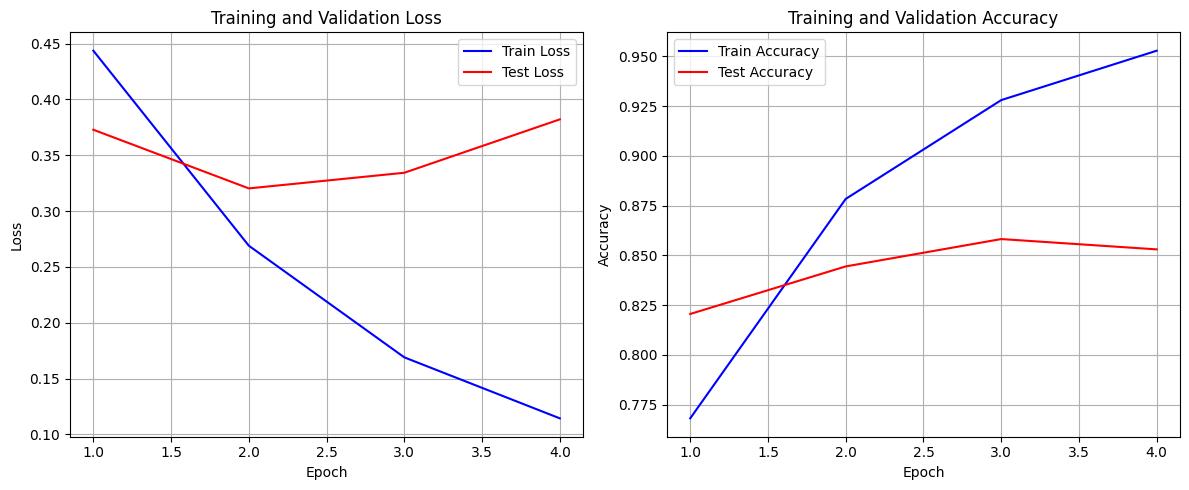

In [194]:
plot_metrics(history, max_epochs)

## Submission

In [195]:
model.eval()
model.to(device)

all_ids = []
all_probs = []

with torch.no_grad():
    for x_batch, filenames in tqdm(test_loader, desc="Predicting"):
        x_batch = x_batch.to(device)
        logits = model(x_batch).squeeze(1)
        probs = torch.sigmoid(logits)

        all_probs.extend(probs.cpu().numpy().tolist())
        all_ids.extend(f[:-4] for f in filenames)


Predicting:   0%|          | 0/313 [00:00<?, ?it/s]

In [196]:
submission = pd.DataFrame({
    "image_id": all_ids,
    "p_180": all_probs
})

submission.to_csv(OUTPUT_CSV, index=False)
print(f"\nСохранено: {OUTPUT_CSV}")
print(submission.head())
print(f"\nРазмер: {submission.shape}")
print(f"Средняя вероятность: {submission['p_180'].mean():.4f}")
print(f"Мин/Макс: {submission['p_180'].min():.4f} / {submission['p_180'].max():.4f}")


Сохранено: submission.csv
     image_id     p_180
0  test_00000  0.440731
1  test_00001  0.533848
2  test_00002  0.273189
3  test_00003  0.927321
4  test_00004  0.780255

Размер: (20000, 2)
Средняя вероятность: 0.5886
Мин/Макс: 0.0000 / 1.0000


# Вывод по модели №1


* в модели много параметров почти 11М
* заморозка слоев дает плохой результат, модель практически не обучается
* Итоговый результат на тесте дал Brier = 0.30781285 (Сильно хуже, чем на validation), вероятно проблема в однообразном и синтетическом датасете

Результаты модели №1
Epoch 8: Train Acc = 0.9711, Test Acc = 0.9213    Test Brier = 0.0612 

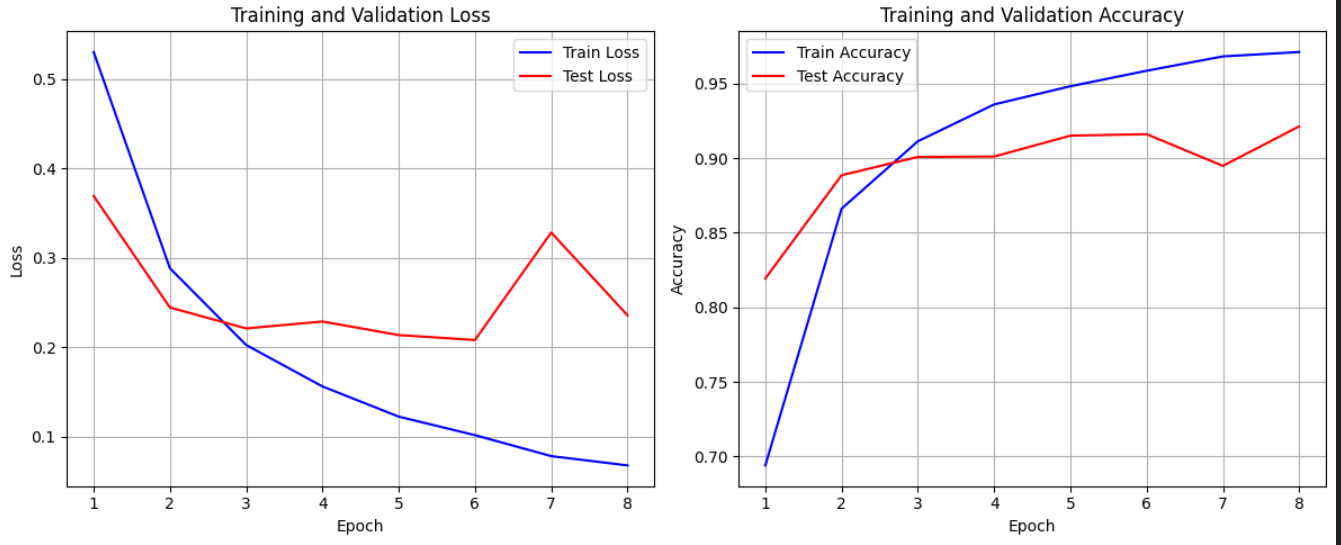 


**План на модель №2:**
1. Переделаю датасет, добавлю фото из реального мира + еще что нибудь
2. Попробую меньшие модели, выберу из них

МНе не хватило времени (письмо о том, что делайн 28.09, пришло 28.09), поэтому делаю все в этом ноутбуке

Также модель только другой датасет
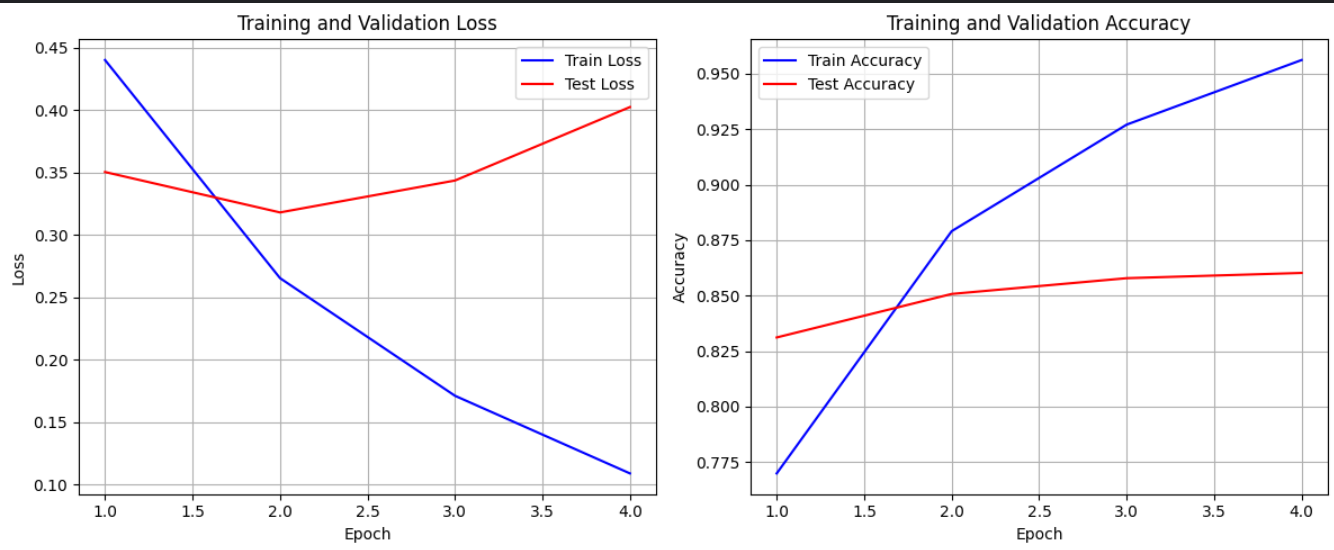 

блин переобучение. вроде даже сделала регуляризацию жестче, но результат хуже (